<a href="https://colab.research.google.com/github/vaishnavichaudhary2812-sudo/IPL-WINNING-TEAM-PREDICTION/blob/main/ipl_data_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IPL WINNING TEAM PREDICTION


1. Importing all the important libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
import os

print(os.getcwd())

/content


2. Loading dataset

In [8]:
import pandas as pd

df = pd.read_csv('/content/ipl match dataset.csv')

3. First 5 rows of dataset

In [9]:
df.head()

,mid,date,venue,batting_team,bowling_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


3. Data Exploration

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   batting_team    76014 non-null  object 
 4   bowling_team    76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [12]:
df.shape

(76014, 15)

In [14]:
df.isnull().sum()

,0
mid,0
date,0
venue,0
batting_team,0
bowling_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


In [16]:
print(df.columns)

Index(['mid', 'date', 'venue', 'batting_team', 'bowling_team', 'batsman',
       'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'striker', 'non-striker', 'total'],
      dtype='object')


4. Feature selection

In [17]:
columns_required = [
    'mid',
    'batting_team',
    'bowling_team',
    'runs',
    'wickets',
    'overs',
    'runs_last_5',
    'wickets_last_5',
    'total'
]

df = df[columns_required]

df.head()

,mid,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
0,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.1,1,0,222
1,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,0.2,1,0,222
2,1,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.2,2,0,222
3,1,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.3,2,0,222
4,1,Kolkata Knight Riders,Royal Challengers Bangalore,2,0,0.4,2,0,222


5. Remove Unwanted Teams

In [21]:
consistent_teams = [
    'Kolkata Knight Riders',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Mumbai Indians',
    'Kings XI Punjab',
    'Royal Challengers Bangalore',
    'Delhi Daredevils',
    'Sunrisers Hyderabad'
]

df = df[(df['batting_team'].isin(consistent_teams)) &
        (df['bowling_team'].isin(consistent_teams))]


6. Keep Data After 5 Overs

In [22]:
df = df[df['overs'] >= 5.0]

print(df.shape)

(40108, 9)


7. One Hot Encoding

In [23]:
df = pd.get_dummies(
    df,
    columns=['batting_team', 'bowling_team'],
    drop_first=True
)

df.head()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,total,batting_team_Delhi Daredevils,batting_team_Kings XI Punjab,batting_team_Kolkata Knight Riders,...,batting_team_Rajasthan Royals,batting_team_Royal Challengers Bangalore,batting_team_Sunrisers Hyderabad,bowling_team_Delhi Daredevils,bowling_team_Kings XI Punjab,bowling_team_Kolkata Knight Riders,bowling_team_Mumbai Indians,bowling_team_Rajasthan Royals,bowling_team_Royal Challengers Bangalore,bowling_team_Sunrisers Hyderabad
32,1,61,0,5.1,59,0,222,False,False,True,...,False,False,False,False,False,False,False,False,True,False
33,1,61,1,5.2,59,1,222,False,False,True,...,False,False,False,False,False,False,False,False,True,False
34,1,61,1,5.3,59,1,222,False,False,True,...,False,False,False,False,False,False,False,False,True,False
35,1,61,1,5.4,59,1,222,False,False,True,...,False,False,False,False,False,False,False,False,True,False
36,1,61,1,5.5,58,1,222,False,False,True,...,False,False,False,False,False,False,False,False,True,False


8. Split Features and Target

In [24]:
X = df.drop('total', axis=1)
y = df['total']

print(X.shape)
print(y.shape)

(40108, 20)
(40108,)


9. Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(32086, 20)
(8022, 20)


10. Train Model

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


11. Predictions

In [28]:
y_pred = lr.predict(X_test)

print(y_pred[:10])

[168.23420043 174.24853047 166.37430003 125.77172453 141.98947989
 162.07307859 155.0618695   97.70406656 135.74990611 135.78614239]


12. Model Evaluation

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 12.92730799691849
Root Mean Squared Error : 17.21794035232995
R² Score : 0.6683361782553974


In [35]:
sample = X.iloc[0].values.reshape(1, -1)

prediction = lr.predict(sample)

print("Predicted Score :", prediction[0])

Predicted Score : 187.2784452261938


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**DATA VISUALIZATION**

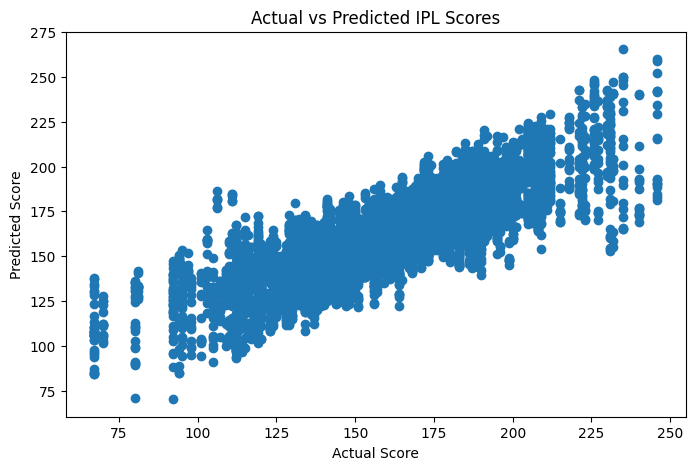

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted IPL Scores")

plt.show()

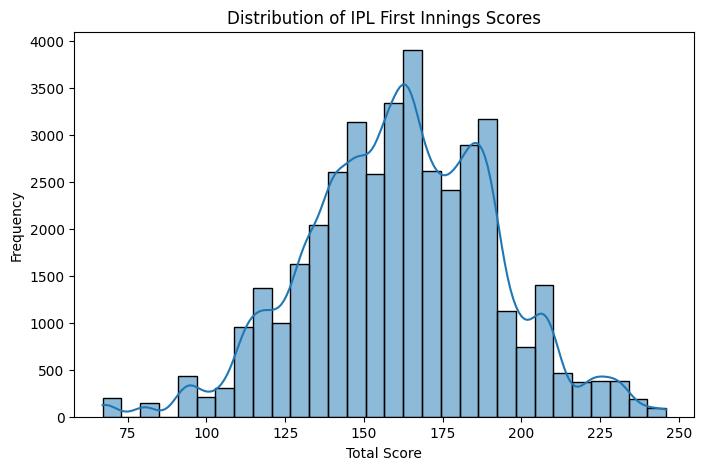

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['total'], bins=30, kde=True)

plt.title('Distribution of IPL First Innings Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')

plt.show()

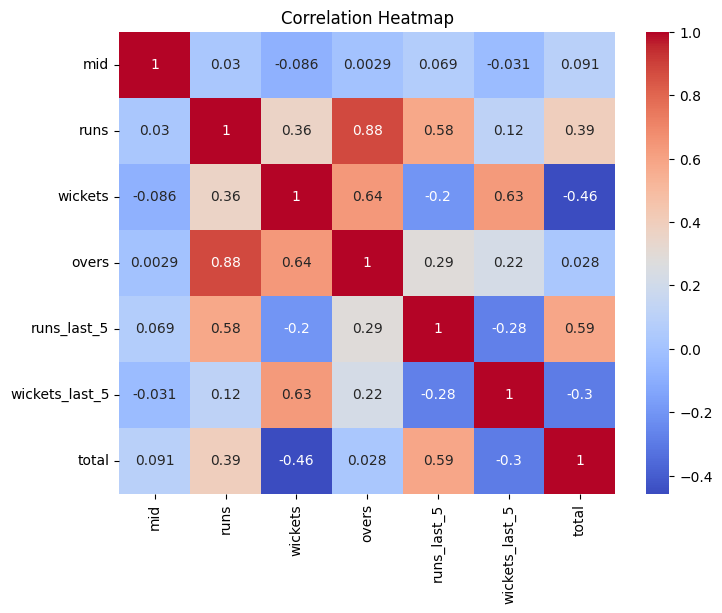

In [33]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
11,batting_team_Royal Challengers Bangalore,2.192515
9,batting_team_Mumbai Indians,1.613695
14,bowling_team_Kings XI Punjab,1.531883
1,runs,0.972355
13,bowling_team_Delhi Daredevils,0.748977
18,bowling_team_Royal Challengers Bangalore,0.424479
17,bowling_team_Rajasthan Royals,0.330170
7,batting_team_Kings XI Punjab,0.066978
0,mid,0.004588
4,runs_last_5,-0.031725
